# ERA5 Tensor-Var 4D-Var

This notebook walks through the **Tensor-Var** formulation of 4-dimensional variational data assimilation (4D-Var) on a single bundled ERA5 sample. Tensor-Var lifts the assimilation problem into a finite-dimensional learned feature space where the dynamics are linear and the cost reduces to a convex quadratic program. The result is a 5-channel atmospheric analysis trajectory (geopotential, temperature, humidity, zonal/meridional wind) on a $64\times 32$ lat-lon grid over a 5-step assimilation window.

**The notebook only loads precomputed results from `evaluation/reference_outputs/` so it runs in seconds.** The boxed cell at the bottom shows how to regenerate everything from scratch by running `main.py`.

Pipeline at a glance:

$$\underbrace{o_{t-9:t}}_{\text{obs window}} \xrightarrow{\phi_O} \underbrace{s_t}_{\text{pseudo-state}} \xrightarrow{\phi_S} \underbrace{\tilde z_t}_{\text{obs feature}} \xrightarrow{\text{QP}} \underbrace{z^\star_t}_{\text{analysis feature}} \xrightarrow{\phi_S^{-1}} \hat x_t.$$

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

TASK_DIR = Path.cwd().parent
sys.path.insert(0, str(TASK_DIR))

from src.visualization import (
    CHANNEL_NAMES,
    compute_metrics_per_channel,
    plot_all_channels,
    print_metrics_table,
)

## 1. Load the bundled sample and the precomputed analysis

`raw_data.npz` holds the 5-step rolling observation history $\mathbf o_{1:5}$, the per-channel min/max for de-normalisation, and the latitude weighting matrix used by the weighted-NRMSE metric. `ground_truth.npz` holds the true state sequence $x_{1:5}$ in normalised space. The analysis trajectory $\hat x_{1:5}$ produced by `main.py` lives in `evaluation/reference_outputs/trajectory.npy`.

In [2]:
raw = np.load(TASK_DIR / 'data' / 'raw_data.npz')
gt = np.load(TASK_DIR / 'data' / 'ground_truth.npz')
with (TASK_DIR / 'data' / 'meta_data.json').open('r') as fh:
    meta = json.load(fh)

obs_history = raw['obs_history'][0]              # (T, history_len*C, H, W)
lat_weight = raw['lat_weight_matrix'][0]         # (C, H, W)
max_val = raw['max_val'][0]
min_val = raw['min_val'][0]
state_true = gt['state'][0]                      # (T, C, H, W)

ref_dir = TASK_DIR / 'evaluation' / 'reference_outputs'
trajectory = np.load(ref_dir / 'trajectory.npy') # (T, C, H, W)
qp_result = np.load(ref_dir / 'qp_result.npy')   # (T, D)
K_S_seq_z = np.load(ref_dir / 'K_S_seq_z.npy')   # (T, D)
inv_obs_seq_z = np.load(ref_dir / 'inv_obs_seq_z.npy')  # (T, C, H, W)

print(f"Channels:           {meta['channels']}")
print(f"Grid:               {meta['grid_height']} x {meta['grid_width']}")
print(f"obs_history shape:  {obs_history.shape}")
print(f"state_true shape:   {state_true.shape}")
print(f"trajectory shape:   {trajectory.shape}")
print(f"qp_result shape:    {qp_result.shape}  (latent dim D = {qp_result.shape[1]})")

Channels:           ['geopotential', 'temperature', 'humidity', 'wind_u', 'wind_v']
Grid:               64 x 32
obs_history shape:  (5, 50, 64, 32)
state_true shape:   (5, 5, 64, 32)
trajectory shape:   (5, 5, 64, 32)
qp_result shape:    (5, 512)  (latent dim D = 512)


## 2. Forward model in pictures

Let's look at the data flowing through the Tensor-Var pipeline. Observations live in a 50-channel tensor (10 historical timesteps $\times$ 5 physical channels), so we visualise just the most recent slice for each physical channel. The geopotential channel (top-left of every panel) is the dominant large-scale feature.

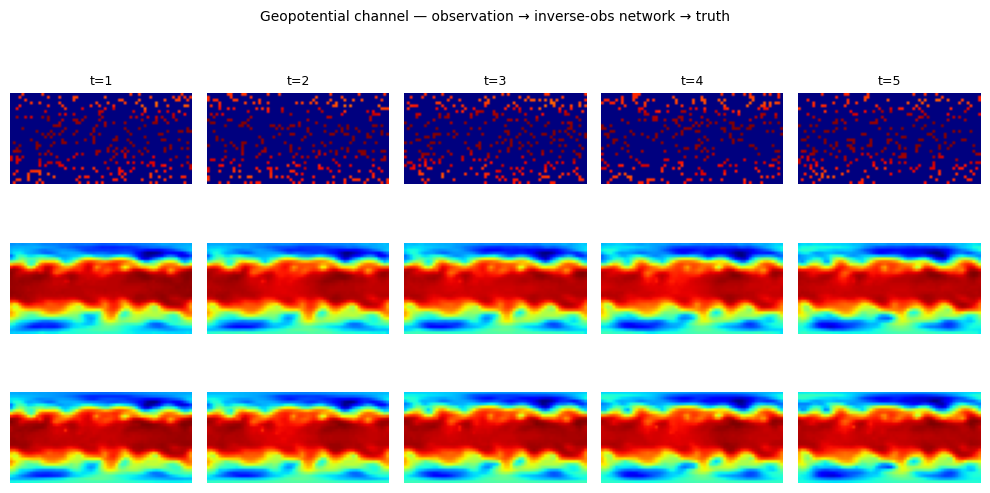

In [3]:
C, H, W = 5, 64, 32
history_len = meta['history_len']
T = obs_history.shape[0]

# Most recent observation per timestep, reshaped from (history_len*C, H, W) -> (history_len, C, H, W)
obs_recent = obs_history.reshape(T, history_len, C, H, W)[:, -1]  # (T, C, H, W)
inv_obs_field = inv_obs_seq_z                                       # (T, C, H, W)

fig, axes = plt.subplots(3, T, figsize=(2.0 * T, 5.5))
for t in range(T):
    axes[0, t].imshow(obs_recent[t, 0].T, cmap='jet')
    axes[1, t].imshow(inv_obs_field[t, 0].T, cmap='jet')
    axes[2, t].imshow(state_true[t, 0].T, cmap='jet')
    axes[0, t].set_title(f't={t+1}', fontsize=9)
    for r in range(3):
        axes[r, t].axis('off')
axes[0, 0].set_ylabel('observation\n(latest)', fontsize=9)
axes[1, 0].set_ylabel(r'$\phi_O(o)$', fontsize=9)
axes[2, 0].set_ylabel('truth', fontsize=9)
fig.suptitle('Geopotential channel — observation → inverse-obs network → truth', fontsize=10)
fig.tight_layout()

## 3. The 4D-Var cost in feature space

Tensor-Var minimises

$$
J(z_{0:T}) = \underbrace{(z_0 - z_b)^\top B (z_0 - z_b)}_{\text{background term}}
             + \sum_{t=0}^{T-1}\underbrace{(z_t - \tilde z_t)^\top R (z_t - \tilde z_t)}_{\text{observation term}}
             + \sum_{t=1}^{T-1} w_t\,\underbrace{(z_t - F^\top z_{t-1})^\top Q (z_t - F^\top z_{t-1})}_{\text{dynamics term}}
$$

where $z_b \in \mathbb R^{D}$ is the climatological feature mean, $\tilde z_t = \phi_S(\phi_O(o_{t-9:t}))$ is the observation feature, $F \in \mathbb R^{D\times D}$ is the linear feature-space dynamics, and the penalty $w_t = \mathrm{linspace}(1, 0.1, T-1)_{T-1-t}$ down-weights the dynamics term toward the end of the window. With $T = 5$ and $D = 512$ this is a convex QP of size $2560$ that `cvxpy` solves in about a second on CPU.

The cell below verifies that the analysed feature trajectory $z^\star_{1:5}$ stays close to the observation features $\tilde z_{1:5}$ — Tensor-Var does not throw the data away.

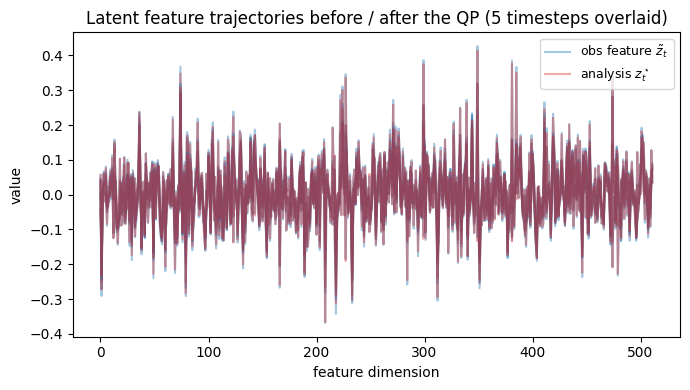

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for t in range(T):
    ax.plot(K_S_seq_z[t], color='tab:blue', alpha=0.4, label='obs feature $\\tilde z_t$' if t == 0 else None)
    ax.plot(qp_result[t],  color='tab:red',  alpha=0.4, label='analysis $z^\\star_t$'    if t == 0 else None)
ax.set_xlabel('feature dimension')
ax.set_ylabel('value')
ax.set_title('Latent feature trajectories before / after the QP (5 timesteps overlaid)')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()

## 4. Per-channel reconstruction quality

All five physical channels are scored. We report:

* **NCC**: cosine similarity between flattened reconstruction and reference (no mean subtraction).
* **NRMSE**: $\sqrt{\overline{(\hat x_c - x_c)^2}} \,/\, (\max x_c - \min x_c)$, computed channel by channel on the normalised fields.
* **wNRMSE** (weighted relative error): $\overline{\| (\hat x_t - x_t)\odot w \|_2 \,/\, \| x_t \odot w \|_2}$, where $w$ is the cosine-latitude weighting matrix shipped in `raw_data.npz`. This is the metric used in the upstream paper to compare with operational baselines.

In [5]:
metrics = compute_metrics_per_channel(trajectory, state_true, lat_weight)
print_metrics_table(metrics)

channel             NCC    NRMSE     wNRMSE
--------------------------------------------
geopotential     0.9999   0.0129     0.0087
temperature      0.9998   0.0173     0.0127
humidity         0.9988   0.0221     0.0450
wind_u           0.9993   0.0268     0.0329
wind_v           0.9992   0.0290     0.0326
--------------------------------------------
mean             0.9994   0.0216     0.0264


## 5. Visual comparison: every channel, every timestep

For each channel we plot two rows — the Tensor-Var analysis on top and the ground truth on the bottom — over the five assimilation timesteps. Geopotential and humidity dominate the dynamics; the wind components carry the highest relative error because they are the noisiest fields.

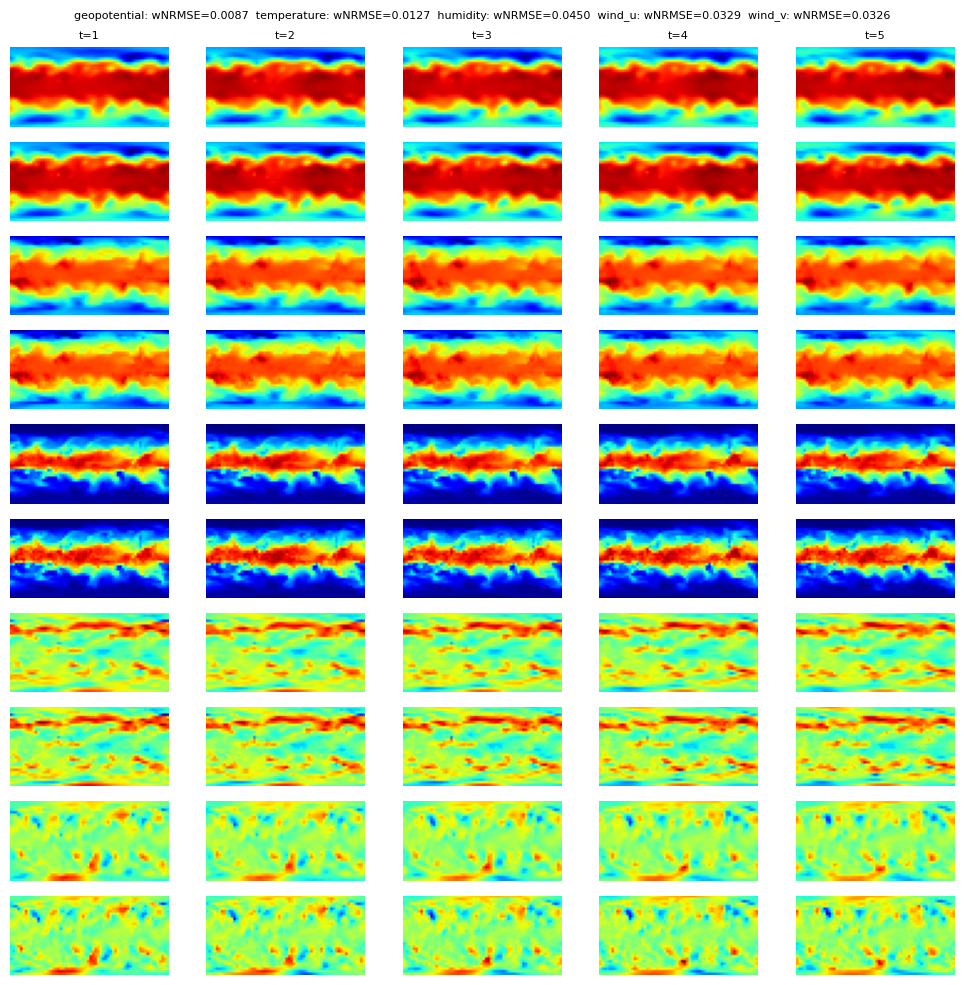

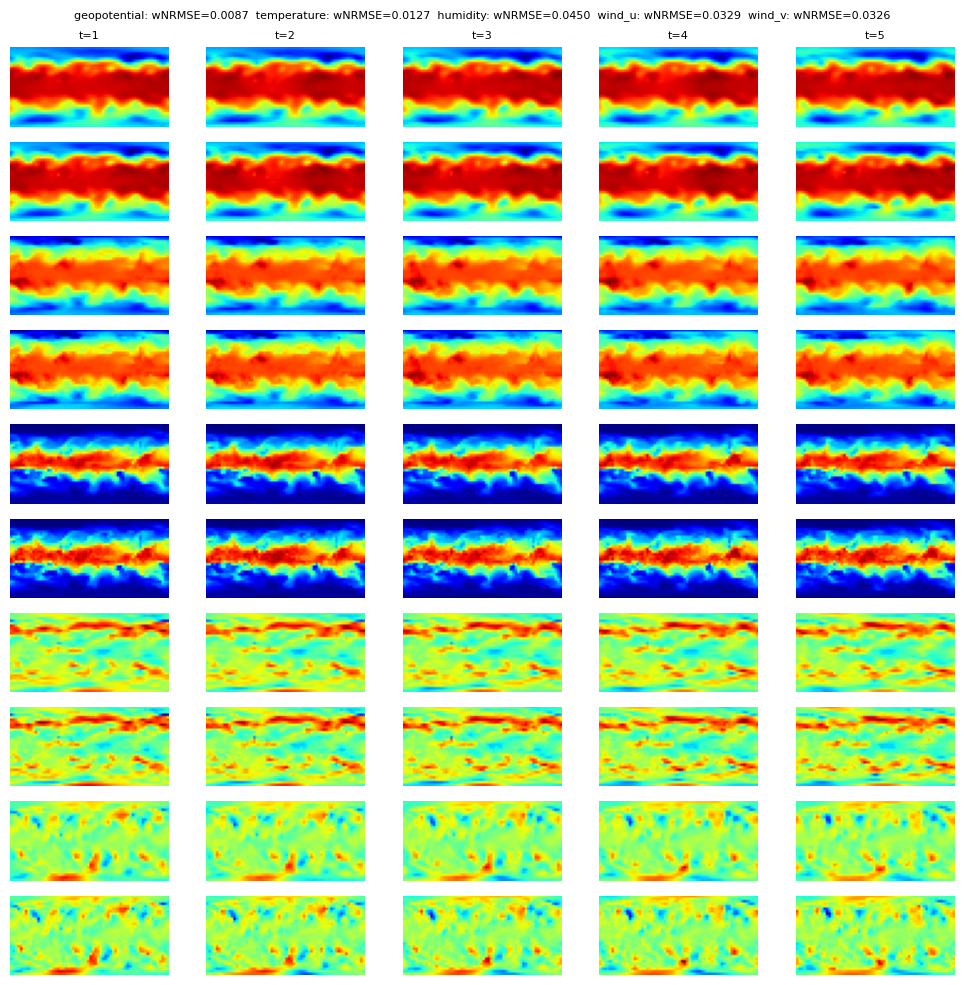

In [6]:
fig = plot_all_channels(trajectory, state_true, metrics)
fig

## 6. Reproducing the analysis from scratch

All the artefacts loaded above are produced by `main.py`. Running it from a fresh checkout will:

1. Download the four pretrained `.pt` checkpoints (≈30 MB) from the upstream Tensor-Var Google Drive release into `evaluation/checkpoints/`.
2. Build the encoder/decoder/inverse-obs networks and load their state dicts.
3. Run `tensor_var_4dvar` on the bundled sample (one assimilation window of length 5).
4. Save `trajectory.npy`, `inv_obs_seq_z.npy`, `K_S_seq_z.npy`, `qp_result.npy`, `metrics.json`, and `comparison.png` into `evaluation/reference_outputs/`.

Uncomment the cell below to re-run end-to-end. Expect ~1 s of QP time on CPU plus a one-off download.

In [7]:
# !python ../main.py